## Threshold Calibration

Compute numeric density (via pdfplumber) for labelled table/non-table pages,
then sweep thresholds to find the optimal cutoff for table detection.

In [1]:
import json
import re
from pathlib import Path

import pdfplumber
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ROOT = Path.cwd().parent.parent
GT_PATH = ROOT / "data" / "interim" / "table_page_ground_truth.json"

NUMERIC_RE = re.compile(r"\b\d+([.,]\d+)*\b")


def numeric_density(words: list[dict]) -> float:
    """Fraction of words that are purely numeric."""
    if not words:
        return 0.0
    texts = [w["text"] for w in words]
    hits = sum(1 for t in texts if NUMERIC_RE.fullmatch(t.strip(",.")))
    return hits / len(texts)


gt = json.loads(GT_PATH.read_text())
print(f"Loaded ground truth: {list(gt.keys())}")

Loaded ground truth: ['antam_ar2016', 'anglo_american_ar2019']


In [ ]:
# Compute density for every labelled page
rows = []
for doc_key, doc in gt.items():
    pdf_path = ROOT / doc["pdf"]
    if not pdf_path.exists():
        print(f"SKIP {pdf_path}")
        continue
    with pdfplumber.open(pdf_path) as pdf:
        for page_idx in doc["table_pages"]:
            if page_idx < len(pdf.pages):
                words = pdf.pages[page_idx].extract_words()
                rows.append({"doc": doc_key, "page": page_idx, "is_table": True, "density": numeric_density(words)})
        for page_idx in doc["non_table_pages"]:
            if page_idx < len(pdf.pages):
                words = pdf.pages[page_idx].extract_words()
                rows.append({"doc": doc_key, "page": page_idx, "is_table": False, "density": numeric_density(words)})

df = pd.DataFrame(rows).sort_values("density")
df

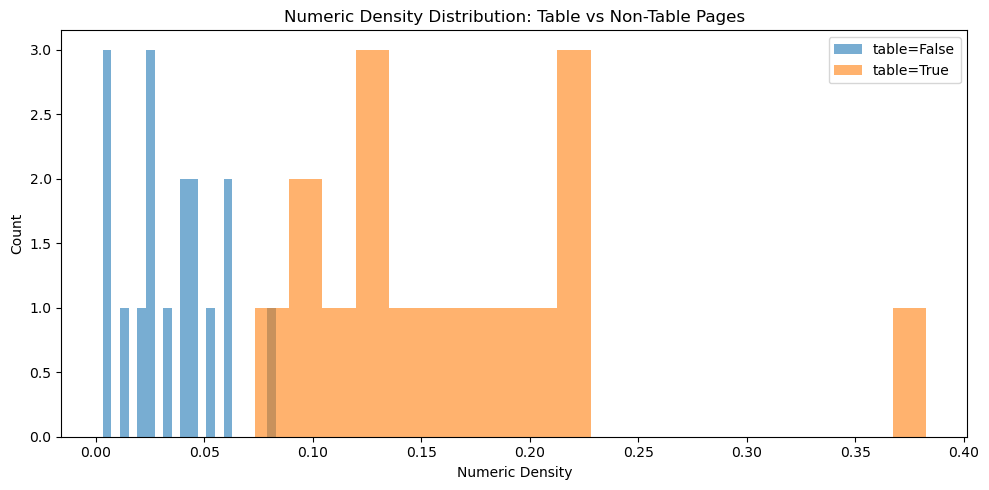

In [4]:
# Visualise density distribution by label
fig, ax = plt.subplots(figsize=(10, 5))
for label, group in df.groupby("is_table"):
    ax.hist(group["density"], bins=20, alpha=0.6, label=f"table={label}")
ax.set_xlabel("Numeric Density")
ax.set_ylabel("Count")
ax.set_title("Numeric Density Distribution: Table vs Non-Table Pages")
ax.legend()
plt.tight_layout()
plt.show()

In [5]:
# Threshold sweep
thresholds = [0.02, 0.03, 0.04, 0.05, 0.06, 0.08, 0.10, 0.12, 0.15, 0.20]
sweep_rows = []
for thresh in thresholds:
    tp = ((df["is_table"]) & (df["density"] >= thresh)).sum()
    fn = ((df["is_table"]) & (df["density"] < thresh)).sum()
    fp = ((~df["is_table"]) & (df["density"] >= thresh)).sum()
    tn = ((~df["is_table"]) & (df["density"] < thresh)).sum()
    acc = (tp + tn) / len(df)
    prec = tp / (tp + fp) if (tp + fp) else 0
    rec = tp / (tp + fn) if (tp + fn) else 0
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0
    sweep_rows.append({"threshold": thresh, "TP": tp, "FP": fp, "FN": fn, "TN": tn, "accuracy": acc, "precision": prec, "recall": rec, "F1": f1})

sweep_df = pd.DataFrame(sweep_rows)
sweep_df

,threshold,TP,FP,FN,TN,accuracy,precision,recall,F1
0,0.02,16,13,0,4,0.606061,0.551724,1.0000,0.711111
1,0.03,16,9,0,8,0.727273,0.640000,1.0000,0.780488
2,0.04,16,8,0,9,0.757576,0.666667,1.0000,0.800000
3,0.05,16,4,0,13,0.878788,0.800000,1.0000,0.888889
4,0.06,16,2,0,15,0.939394,0.888889,1.0000,0.941176
5,0.08,15,1,1,16,0.939394,0.937500,0.9375,0.937500
6,0.10,14,0,2,17,0.939394,1.000000,0.8750,0.933333
7,0.12,12,0,4,17,0.878788,1.000000,0.7500,0.857143
8,0.15,8,0,8,17,0.757576,1.000000,0.5000,0.666667
9,0.20,5,0,11,17,0.666667,1.000000,0.3125,0.476190


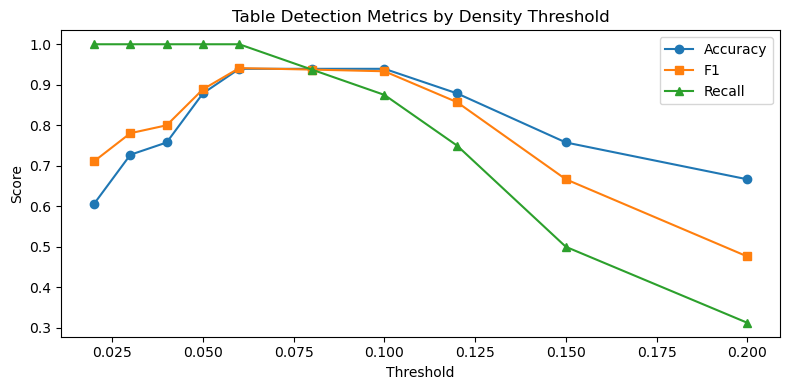

In [6]:
# Plot F1 / accuracy vs threshold
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sweep_df["threshold"], sweep_df["accuracy"], marker="o", label="Accuracy")
ax.plot(sweep_df["threshold"], sweep_df["F1"], marker="s", label="F1")
ax.plot(sweep_df["threshold"], sweep_df["recall"], marker="^", label="Recall")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_title("Table Detection Metrics by Density Threshold")
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# Print recommended threshold (max F1)
best = sweep_df.loc[sweep_df["F1"].idxmax()]
print(f"Recommended threshold: {best['threshold']:.2f}")
print(f"  F1={best['F1']:.2f}  accuracy={best['accuracy']:.2f}  precision={best['precision']:.2f}  recall={best['recall']:.2f}")

Recommended threshold: 0.06
  F1=0.94  accuracy=0.94  precision=0.89  recall=1.00
